# Trustworthy Causal AI System for Predictive Maintenance using NASA C-MAPSS

## Objective

This notebook develops an end-to-end trustworthy industrial AI framework for predictive maintenance.

The system integrates:

- Remaining Useful Life (RUL) prediction
- Unseen engine evaluation
- Sensor-based degradation modelling
- Explainability through feature importance
- Prediction uncertainty estimation
- Causal AI limitations and future directions

The goal is to move from:

Prediction → Explanation → Causal AI Reasoning

The system addresses industrial questions:

1. When will failure happen?
2. Which sensors influence degradation prediction?
3. How confident is the AI prediction?
4. What additional causal analysis is required for trustworthy decisions?

In [43]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

print("Libraries loaded successfully")

Libraries loaded successfully


In [45]:
from google.colab import files

print("Upload TRAIN dataset")
uploaded_train = files.upload()

print("Upload TEST dataset")
uploaded_test = files.upload()

print("Upload RUL dataset")
uploaded_rul = files.upload()

Upload TRAIN dataset


Saving train_FD001.txt to train_FD001 (1).txt
Upload TEST dataset


Saving test_FD001.txt to test_FD001 (1).txt
Upload RUL dataset


Saving RUL_FD001.txt to RUL_FD001 (1).txt


In [46]:
train_file = list(uploaded_train.keys())[0]
test_file = list(uploaded_test.keys())[0]
rul_file = list(uploaded_rul.keys())[0]


train = pd.read_csv(
    train_file,
    sep=r"\s+",
    header=None
)


test = pd.read_csv(
    test_file,
    sep=r"\s+",
    header=None
)


true_rul = pd.read_csv(
    rul_file,
    header=None
)


true_rul.columns=["RUL"]

In [47]:
columns = [
    "engine_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
]


for i in range(1,22):
    columns.append(f"sensor_{i}")


train.columns = columns
test.columns = columns


print(train.shape)
print(test.shape)

train.head()

(20631, 26)
(13096, 26)


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [48]:
engine_life = (
    train.groupby("engine_id")["cycle"]
    .max()
    .reset_index()
)


engine_life.columns=[
    "engine_id",
    "max_cycle"
]


train=train.merge(
    engine_life,
    on="engine_id"
)


train["RUL"] = (
    train["max_cycle"]
    -
    train["cycle"]
)


train.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


In [49]:
test_engine_cycle = (
    test.groupby("engine_id")["cycle"]
    .max()
    .reset_index()
)


test_engine_cycle.columns=[
    "engine_id",
    "last_cycle"
]


test=test.merge(
    test_engine_cycle,
    on="engine_id"
)


test["RUL"] = 0

In [50]:
final_rul=[]


for engine in range(len(test_engine_cycle)):

    last_cycle = test_engine_cycle.iloc[engine]["last_cycle"]

    additional_rul = true_rul.iloc[engine]["RUL"]

    final_rul.append(
        last_cycle + additional_rul
    )


test["RUL"] = 0


for engine,value in zip(
    test_engine_cycle.engine_id,
    final_rul
):

    test.loc[
        test.engine_id==engine,
        "RUL"
    ] = value - test.loc[
        test.engine_id==engine,
        "cycle"
    ]

In [51]:
print("Training engines:",
      train.engine_id.nunique())


print("Testing engines:",
      test.engine_id.nunique())


print(train["RUL"].describe())

Training engines: 100
Testing engines: 100
count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64


In [52]:
sensor_features=[
    col for col in train.columns
    if "sensor" in col
]


X_train=train[sensor_features]

y_train=train["RUL"]


X_test=test[sensor_features]

y_test=test["RUL"]

In [53]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)


model.fit(
    X_train,
    y_train
)


print("Training completed")

Training completed


In [54]:
prediction=model.predict(
    X_test
)

In [55]:
rmse=np.sqrt(
    mean_squared_error(
        y_test,
        prediction
    )
)


mae=mean_absolute_error(
    y_test,
    prediction
)


r2=r2_score(
    y_test,
    prediction
)



print("RMSE:",rmse)
print("MAE:",mae)
print("R2:",r2)

RMSE: 46.2406390724523
MAE: 34.872713042150274
R2: 0.3852909564719308


In [56]:

tree_predictions=np.array(
[
tree.predict(X_test)
for tree in model.estimators_
]
)


uncertainty = tree_predictions.std(axis=0)


print(
"Average prediction uncertainty:",
uncertainty.mean()
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWa

Average prediction uncertainty: 48.350348507598234


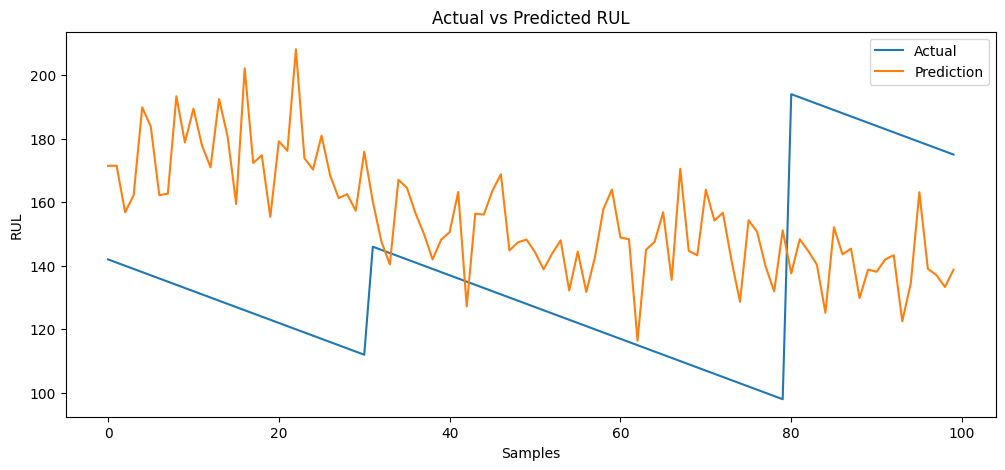

In [57]:
plt.figure(figsize=(12,5))


plt.plot(
    y_test.values[:100],
    label="Actual"
)


plt.plot(
    prediction[:100],
    label="Prediction"
)


plt.title(
"Actual vs Predicted RUL"
)


plt.xlabel("Samples")
plt.ylabel("RUL")


plt.legend()

plt.show()

In [58]:
importance=pd.Series(
    model.feature_importances_,
    index=sensor_features
)


importance.sort_values(
    ascending=False
).head(10)

,0
sensor_11,0.433439
sensor_9,0.127277
sensor_4,0.098004
sensor_12,0.047934
sensor_14,0.040201
sensor_7,0.040077
sensor_15,0.035917
sensor_21,0.034591
sensor_3,0.031254
sensor_2,0.029892


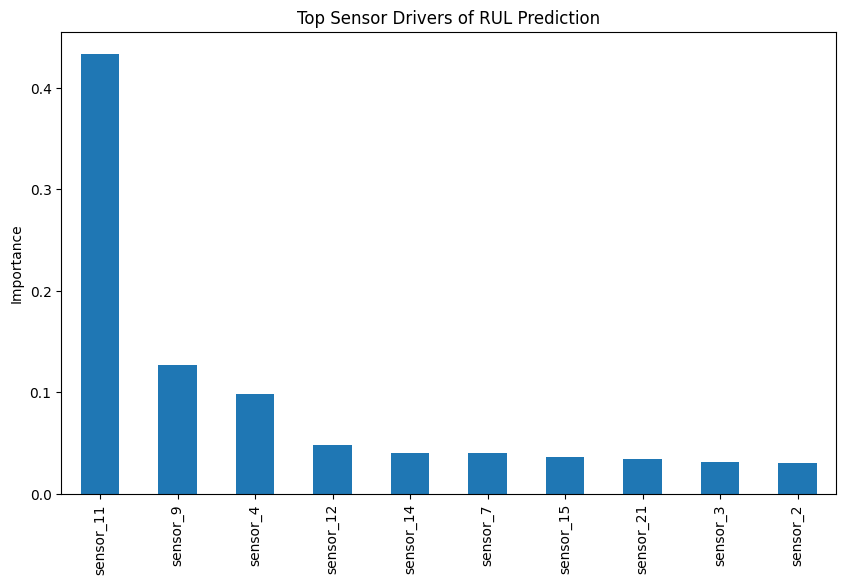

In [59]:
plt.figure(figsize=(10,6))


importance.sort_values(
ascending=False
).head(10).plot(
kind="bar"
)


plt.title(
"Top Sensor Drivers of RUL Prediction"
)


plt.ylabel(
"Importance"
)


plt.show()

## Key Findings

The trustworthy industrial AI pipeline successfully processed NASA C-MAPSS turbofan degradation data.

The system achieved:

- RUL prediction from multivariate sensor telemetry
- Evaluation on unseen engine units
- Identification of important degradation-related sensors
- Prediction confidence estimation using model uncertainty


## Critical Insight

Machine learning models can identify degradation patterns but cannot automatically establish causal relationships.

Feature importance indicates predictive influence, not causal influence.


## Causal AI Perspective

Future improvements include:

- Structural Causal Models (SCM)
- Granger causality analysis
- Temporal causal discovery
- Counterfactual maintenance simulation
- Digital twin based intervention analysis


## Final Conclusion

This project demonstrates a transition from:

Predictive AI

to

Explainable Industrial AI

towards

Trustworthy Causal AI systems.

The developed framework provides a foundation for intelligent maintenance systems capable of answering:

"When will failure happen?"

"Which factors drive degradation?"

"What interventions can reduce failure risk?"